# 2. Building and Customizing Isochrone Grids

In **Tutorial 1** we used the model grids that ship with `ysoisochrone`. Here we do it
the other way round: we **download the raw stellar evolutionary tracks**, **build the
isochrone grid matrix ourselves**, load it back in, plot it, and walk through the
parameters that control how the grid is built.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ysoisochrone

## Download the stellar evolutionary models

To build your own grid you first need the raw tracks. The `download_*` helpers fetch
them from the model authors' servers, so you need internet access. Some models (e.g.
PARSEC, MIST) are large ($\sim 1\,$GB), so make sure you have a few GB free on the disk
where the data is stored.

By default the `download_*` functions create a folder called `isochrones_data` in the
current working directory; pass `save_dir=` to change that.

Let's download the tracks from
[Baraffe et al. (2015)](https://ui.adsabs.harvard.edu/abs/2015A%26A...577A..42B/abstract)
and [Feiden (2016)](https://ui.adsabs.harvard.edu/abs/2016A%26A...593A..99F/abstract).

In [3]:
ysoisochrone.utils.download_baraffe_tracks()

# # download Feiden tracks
# in this notebook, the Feiden tracks are not used, so you can ignore the following line. If you want to use the Feiden tracks, please uncomment the following line to download the Feiden tracks.
# ysoisochrone.utils.download_feiden_trk_tracks()

Downloading: 100%|█████████████████████████████████████████████| 1.35M/1.35M [00:00<00:00, 1.46MB/s]


Downloaded isochrones_data/Baraffe2015/BHAC15_tracks+structure
If you end up using the Baraffe et al. (2015) tracks, please cite from: https://ui.adsabs.harvard.edu/abs/2015A%26A...577A..42B/abstract


1

**NOTE**.
If you want to store the data in a different directory, you can use

``` Python
save_dir_yourpath = 'Your_prefered_path'
ysoisochrone.utils.download_baraffe_tracks(save_dir=save_dir_yourpath)
```

## Build the grid matrix

`ysoisochrone` stores each grid as three arrays in a `.mat` file — `masses`, `log_age`,
and `logtlogl` (a 2-D grid of `log10(Teff)` and `log10(L/Lsun)`). Building one takes
three steps (all wrapped inside `Isochrone.load_baraffe2015_tracks` /
`Isochrone.prepare_baraffe_tracks`):

1. **download** the raw file (done above — it now lives in `./isochrones_data/Baraffe2015/`);
2. **read** it into a flat `data_points` array;
3. **interpolate** those points onto a regular mass/age meshgrid and **save**.

### (i) & (ii) Read the raw tracks

Every model ships its data in a different text format, so there is a reader per model in
`ysoisochrone.utils`: `read_baraffe_file`, `read_feiden_trk_file`,
`read_parsec_v1p2_dat_file`, `read_parsec_v2p0_tab_file`, `read_mist_v1p2_iso_file`, …
(see [all models here](../models.md)). For the Baraffe tracks:

In [4]:
# define the data dir
isochrones_data_dir = os.path.join(os.getcwd(), 'isochrones_data')
input_file = os.path.join(isochrones_data_dir, 'Baraffe2015', 'BHAC15_tracks+structure')

# Read the original BHAC15 tracks file
data_points = ysoisochrone.utils.read_baraffe_file(input_file)

`data_points` is a long array of `[mass, log_age, teff, log_luminosity]` rows — the
original points as provided by the model.

**NOTE** To plug in a completely custom model, the *only* thing you have to produce is
this formatted `data_points` array. `ysoisochrone` does everything after that.

### (iii) Create the meshgrid and save

In [5]:
# Interpolate the raw points onto a regular (mass, log_age) grid
masses_i, log_age_i, logtlogl_grid, masses_grid, log_age_grid = ysoisochrone.utils.create_meshgrid(data_points)

# Save to a .mat file -- this is the grid we will use below
output_mat_file = os.path.join(isochrones_data_dir, 'Your_matrix_Baraffe_AgeMassGrid_YSO_matrix.mat')
ysoisochrone.utils.save_as_mat(masses_i, log_age_i, logtlogl_grid, output_mat_file)
print(f"File saved as: {output_mat_file}")

Data saved to /home/dingshandeng/project/1-Project_ysoisochrone/ysoisochrone/tutorial_notebooks/isochrones_data/Your_matrix_Baraffe_AgeMassGrid_YSO_matrix.mat
File saved as: /home/dingshandeng/project/1-Project_ysoisochrone/ysoisochrone/tutorial_notebooks/isochrones_data/Your_matrix_Baraffe_AgeMassGrid_YSO_matrix.mat


`masses_i, log_age_i, logtlogl_grid` are exactly the three attributes of the `Isochrone`
class (used below); `masses_grid, log_age_grid` are the 2-D mesh points, handy for
checking the interpolation.

The whole download → read → meshgrid → save chain is also available as a single call:

``` Python
ysoisochrone.isochrone.Isochrone(data_dir='isochrones_data').prepare_baraffe_tracks()
```

with a `prepare_*` method for each model (`prepare_feiden_tracks`,
`prepare_parsecv1p2_tracks`, `prepare_parsecv2p0_tracks`, `prepare_mistv1p2_tracks`).

## Load your grid and plot it

Any `.mat` grid — one you just built, or one from elsewhere — is read into the
`Isochrone` class with the `customize` option:

In [6]:
isochrone = ysoisochrone.isochrone.Isochrone()
isochrone.set_tracks('customize', load_file=output_mat_file)

using the user-specified isochrone matrix of
/home/dingshandeng/project/1-Project_ysoisochrone/ysoisochrone/tutorial_notebooks/isochrones_data/Your_matrix_Baraffe_AgeMassGrid_YSO_matrix.mat
-----------------------


1

Then we can plot the grid we just built:

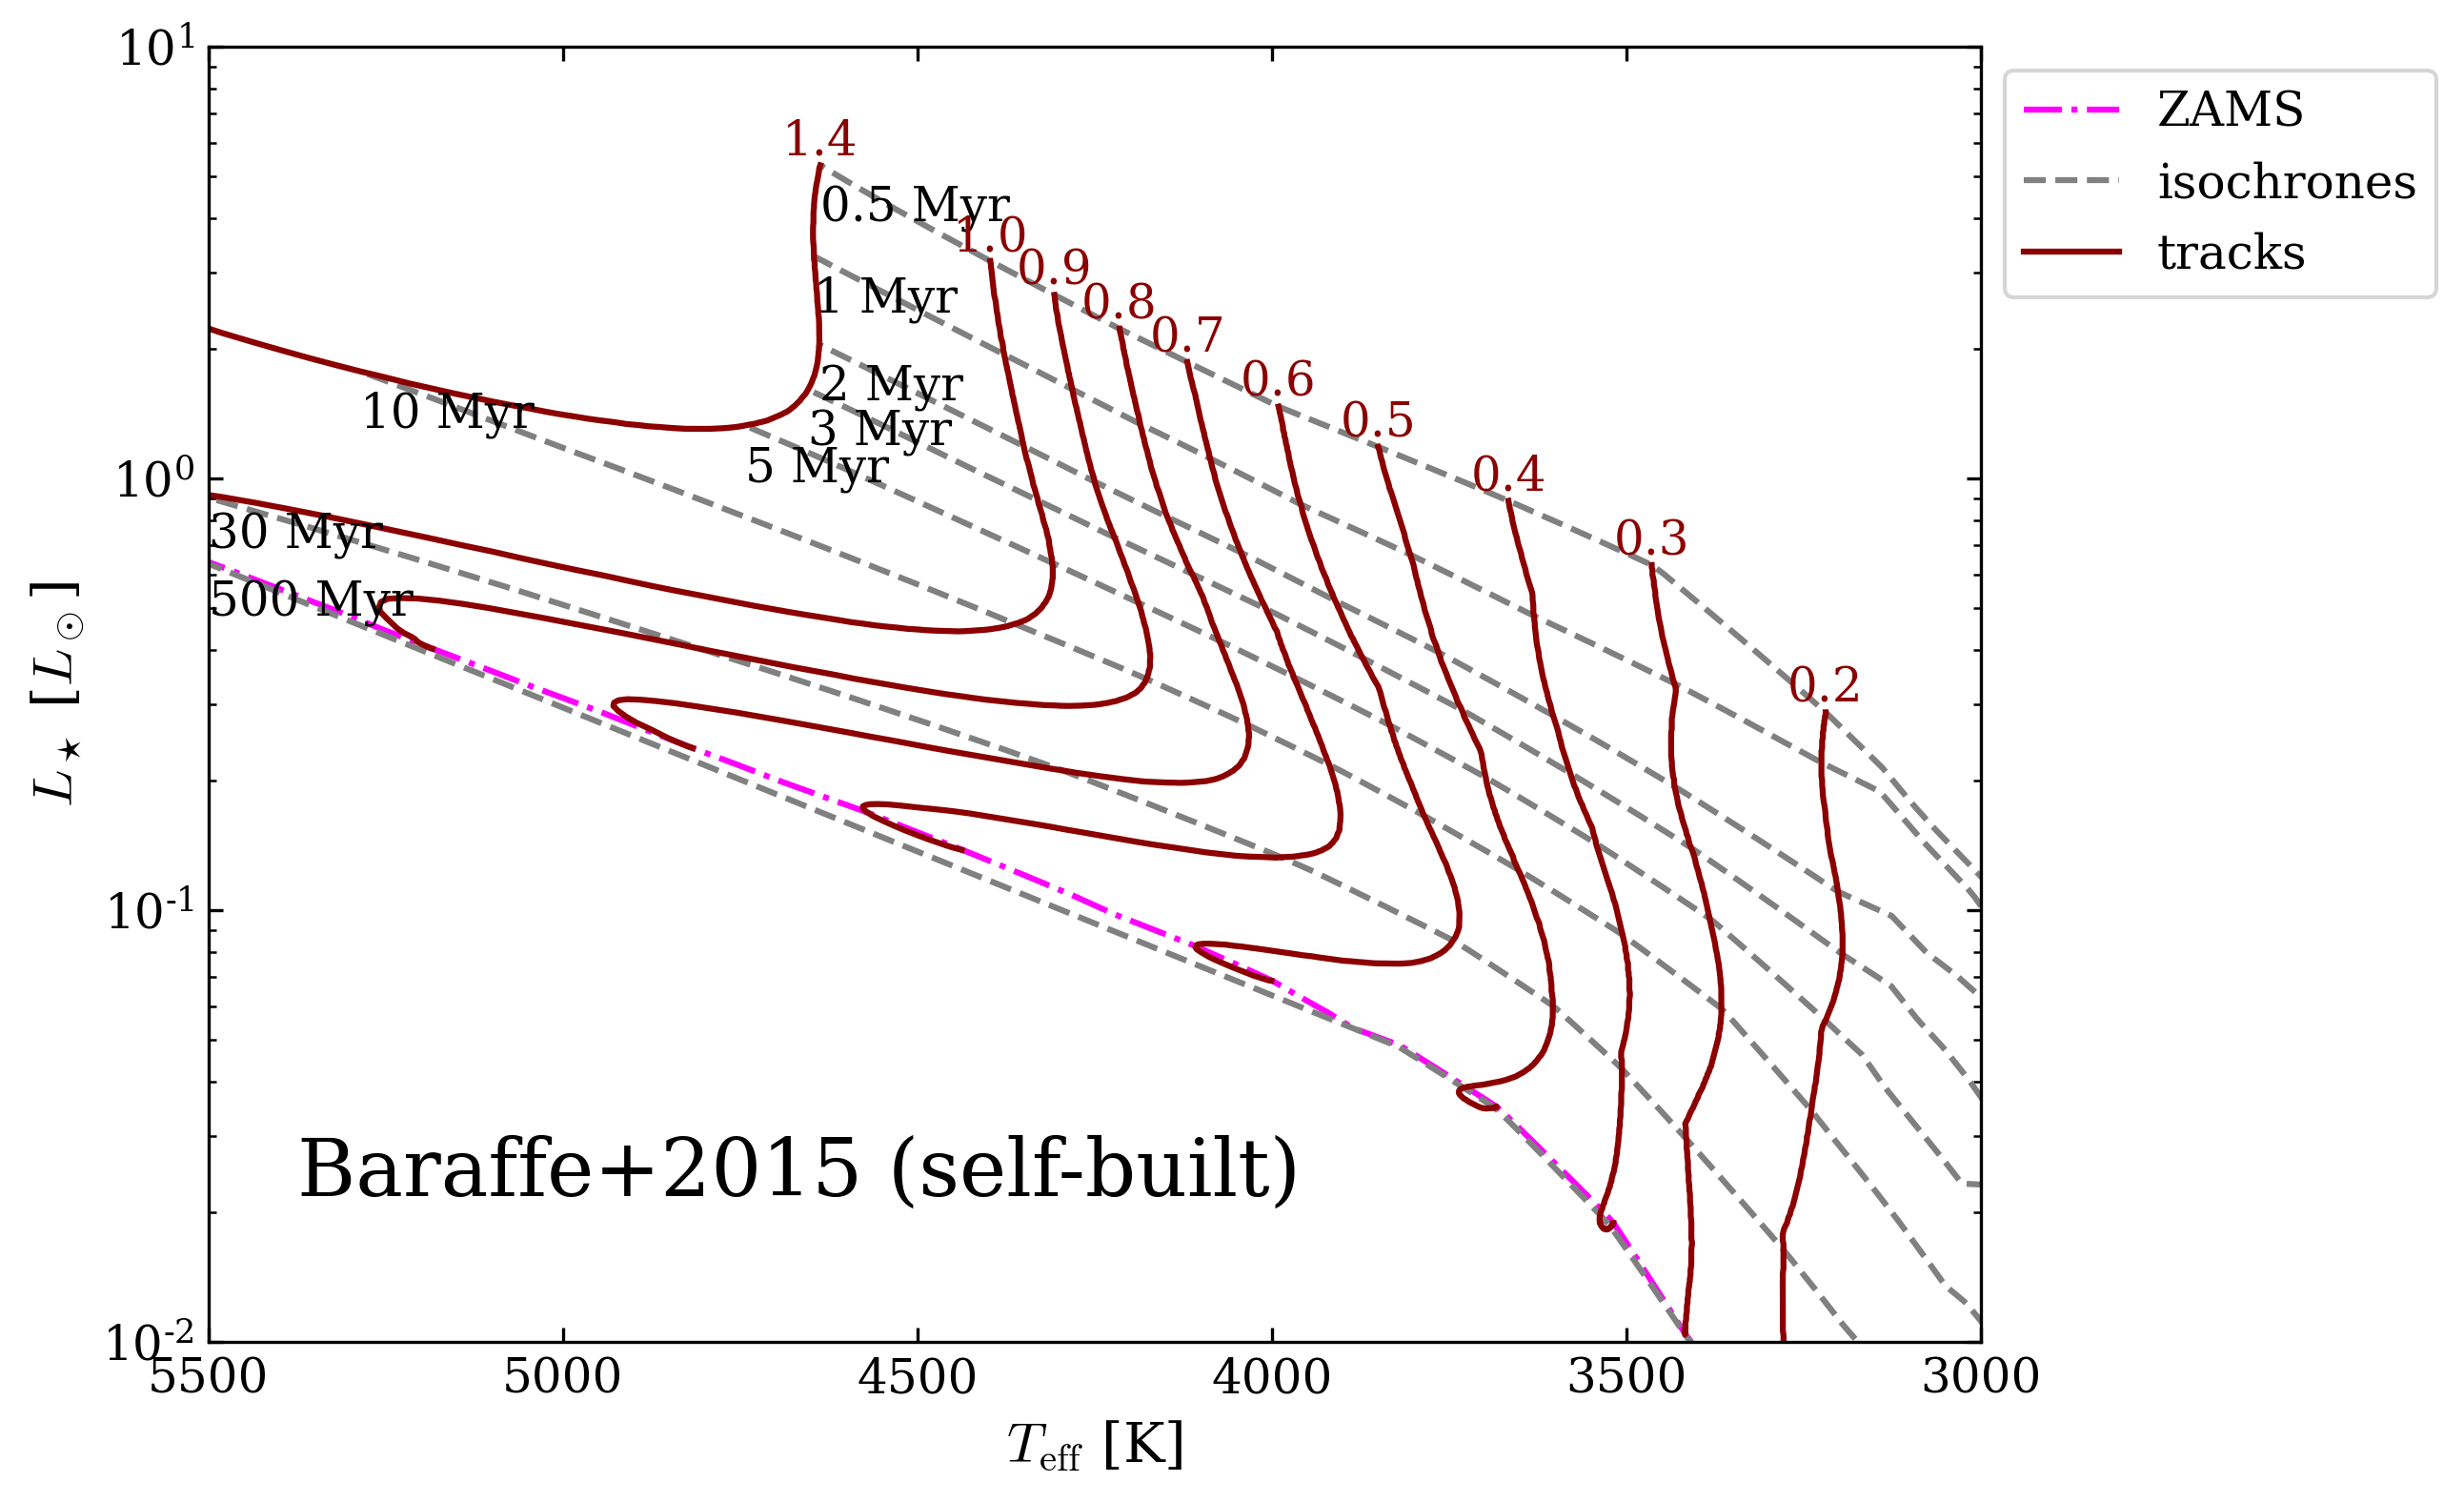

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

ysoisochrone.plotting.plot_hr_diagram(isochrone, ax_set=ax,
                                      ages_to_plot=[0.5e6, 1.0e6, 2.0e6, 3.0e6, 5.0e6, 10.0e6, 30.0e6, 500.0e6],
                                      masses_to_plot=[0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.39],
                                      xlim_set=[5500, 3000], ylim_set=[0.01, 10.0])

ax.annotate('Baraffe+2015 (self-built)', xy=(0.05, 0.1), xycoords='axes fraction', ha='left', va='bottom', fontsize=20)

plt.show()

The `Isochrone` class has three `Attributes`:

- `isochrone.log_age` — grid of `log10(age)` in yr (think of it as the x-axis).
- `isochrone.masses` — grid of `masses` in solar masses (the y-axis).
- `isochrone.logtlogl` — a 2-D grid of `log10(Teff)` [K] and `log10(Luminosity)` [Lsun].

So to get a 2-D grid of Teff and luminosity:

In [8]:
# Convert isochrone logtlogl data to Teff and L/Lo
teff_iso = 10**isochrone.logtlogl[:, :, 0]  # Teff
lum_iso = 10**isochrone.logtlogl[:, :, 1]   # L/Lo

The first index is age and the second is mass, so to pull out a constant-age line or a
constant-mass track:

In [9]:
age = 1.5e6
idx_age = np.nanargmin(np.abs(isochrone.log_age - age))  # Find closest age
teff_thisage = teff_iso[idx_age, :]
lum_thisage = lum_iso[idx_age, :]

mass = 1.0
idx_mass = np.nanargmin(np.abs(isochrone.masses - mass))  # Find closest mass
teff_thismass = teff_iso[:, idx_mass]
lum_thismass = lum_iso[:, idx_mass]

## Grid parameters you can tune

`create_meshgrid` controls the window and resolution of the grid:

``` Python
ysoisochrone.utils.create_meshgrid(
    data_points,
    min_age=0.5, max_age=1000.0,      # Myr  -- age range kept in the grid
    min_mass=0.0, max_mass=7.5,       # Msun -- mass range kept in the grid
    interpolation_method='linear',    # passed to scipy.interpolate.griddata ('linear', 'cubic', 'nearest')
)
```

The defaults span a wide age/mass range so the same machinery also works for older or
intermediate-mass populations. For a classic YSO analysis you often want a tighter
window — e.g. the
[Pascucci et al. (2016)](https://ui.adsabs.harvard.edu/abs/2016ApJ...831..125P/abstract)
choice of $\le 50$ Myr and $\le 1.4\,M_\odot$. Let's build a second grid with a YSO cut
and compare:

In [10]:
# a tighter, YSO-oriented grid
masses_i2, log_age_i2, logtlogl_grid2, _, _ = ysoisochrone.utils.create_meshgrid(
    data_points, min_age=0.5, max_age=30.0, min_mass=0.05, max_mass=1.4)

output_mat_file_ysocut = os.path.join(isochrones_data_dir, 'Your_matrix_Baraffe_YSOcut_AgeMassGrid_matrix.mat')
ysoisochrone.utils.save_as_mat(masses_i2, log_age_i2, logtlogl_grid2, output_mat_file_ysocut)
print(f"File saved as: {output_mat_file_ysocut}")

Data saved to /home/dingshandeng/project/1-Project_ysoisochrone/ysoisochrone/tutorial_notebooks/isochrones_data/Your_matrix_Baraffe_YSOcut_AgeMassGrid_matrix.mat
File saved as: /home/dingshandeng/project/1-Project_ysoisochrone/ysoisochrone/tutorial_notebooks/isochrones_data/Your_matrix_Baraffe_YSOcut_AgeMassGrid_matrix.mat


using the user-specified isochrone matrix of
/home/dingshandeng/project/1-Project_ysoisochrone/ysoisochrone/tutorial_notebooks/isochrones_data/Your_matrix_Baraffe_AgeMassGrid_YSO_matrix.mat
-----------------------
using the user-specified isochrone matrix of
/home/dingshandeng/project/1-Project_ysoisochrone/ysoisochrone/tutorial_notebooks/isochrones_data/Your_matrix_Baraffe_YSOcut_AgeMassGrid_matrix.mat
-----------------------
default (0.5-1000 Myr, 0-7.5 Msun)     | log_age 5.70..9.01 | mass 0.010..1.413 | logtlogl (332, 216, 2)
YSO cut (0.5-30 Myr, 0.05-1.4 Msun)    | log_age 5.70..7.48 | mass 0.050..1.409 | logtlogl (179, 146, 2)
100.00 Myrs is skipped because it is larger than the grid max mass of 30.13 Myrs


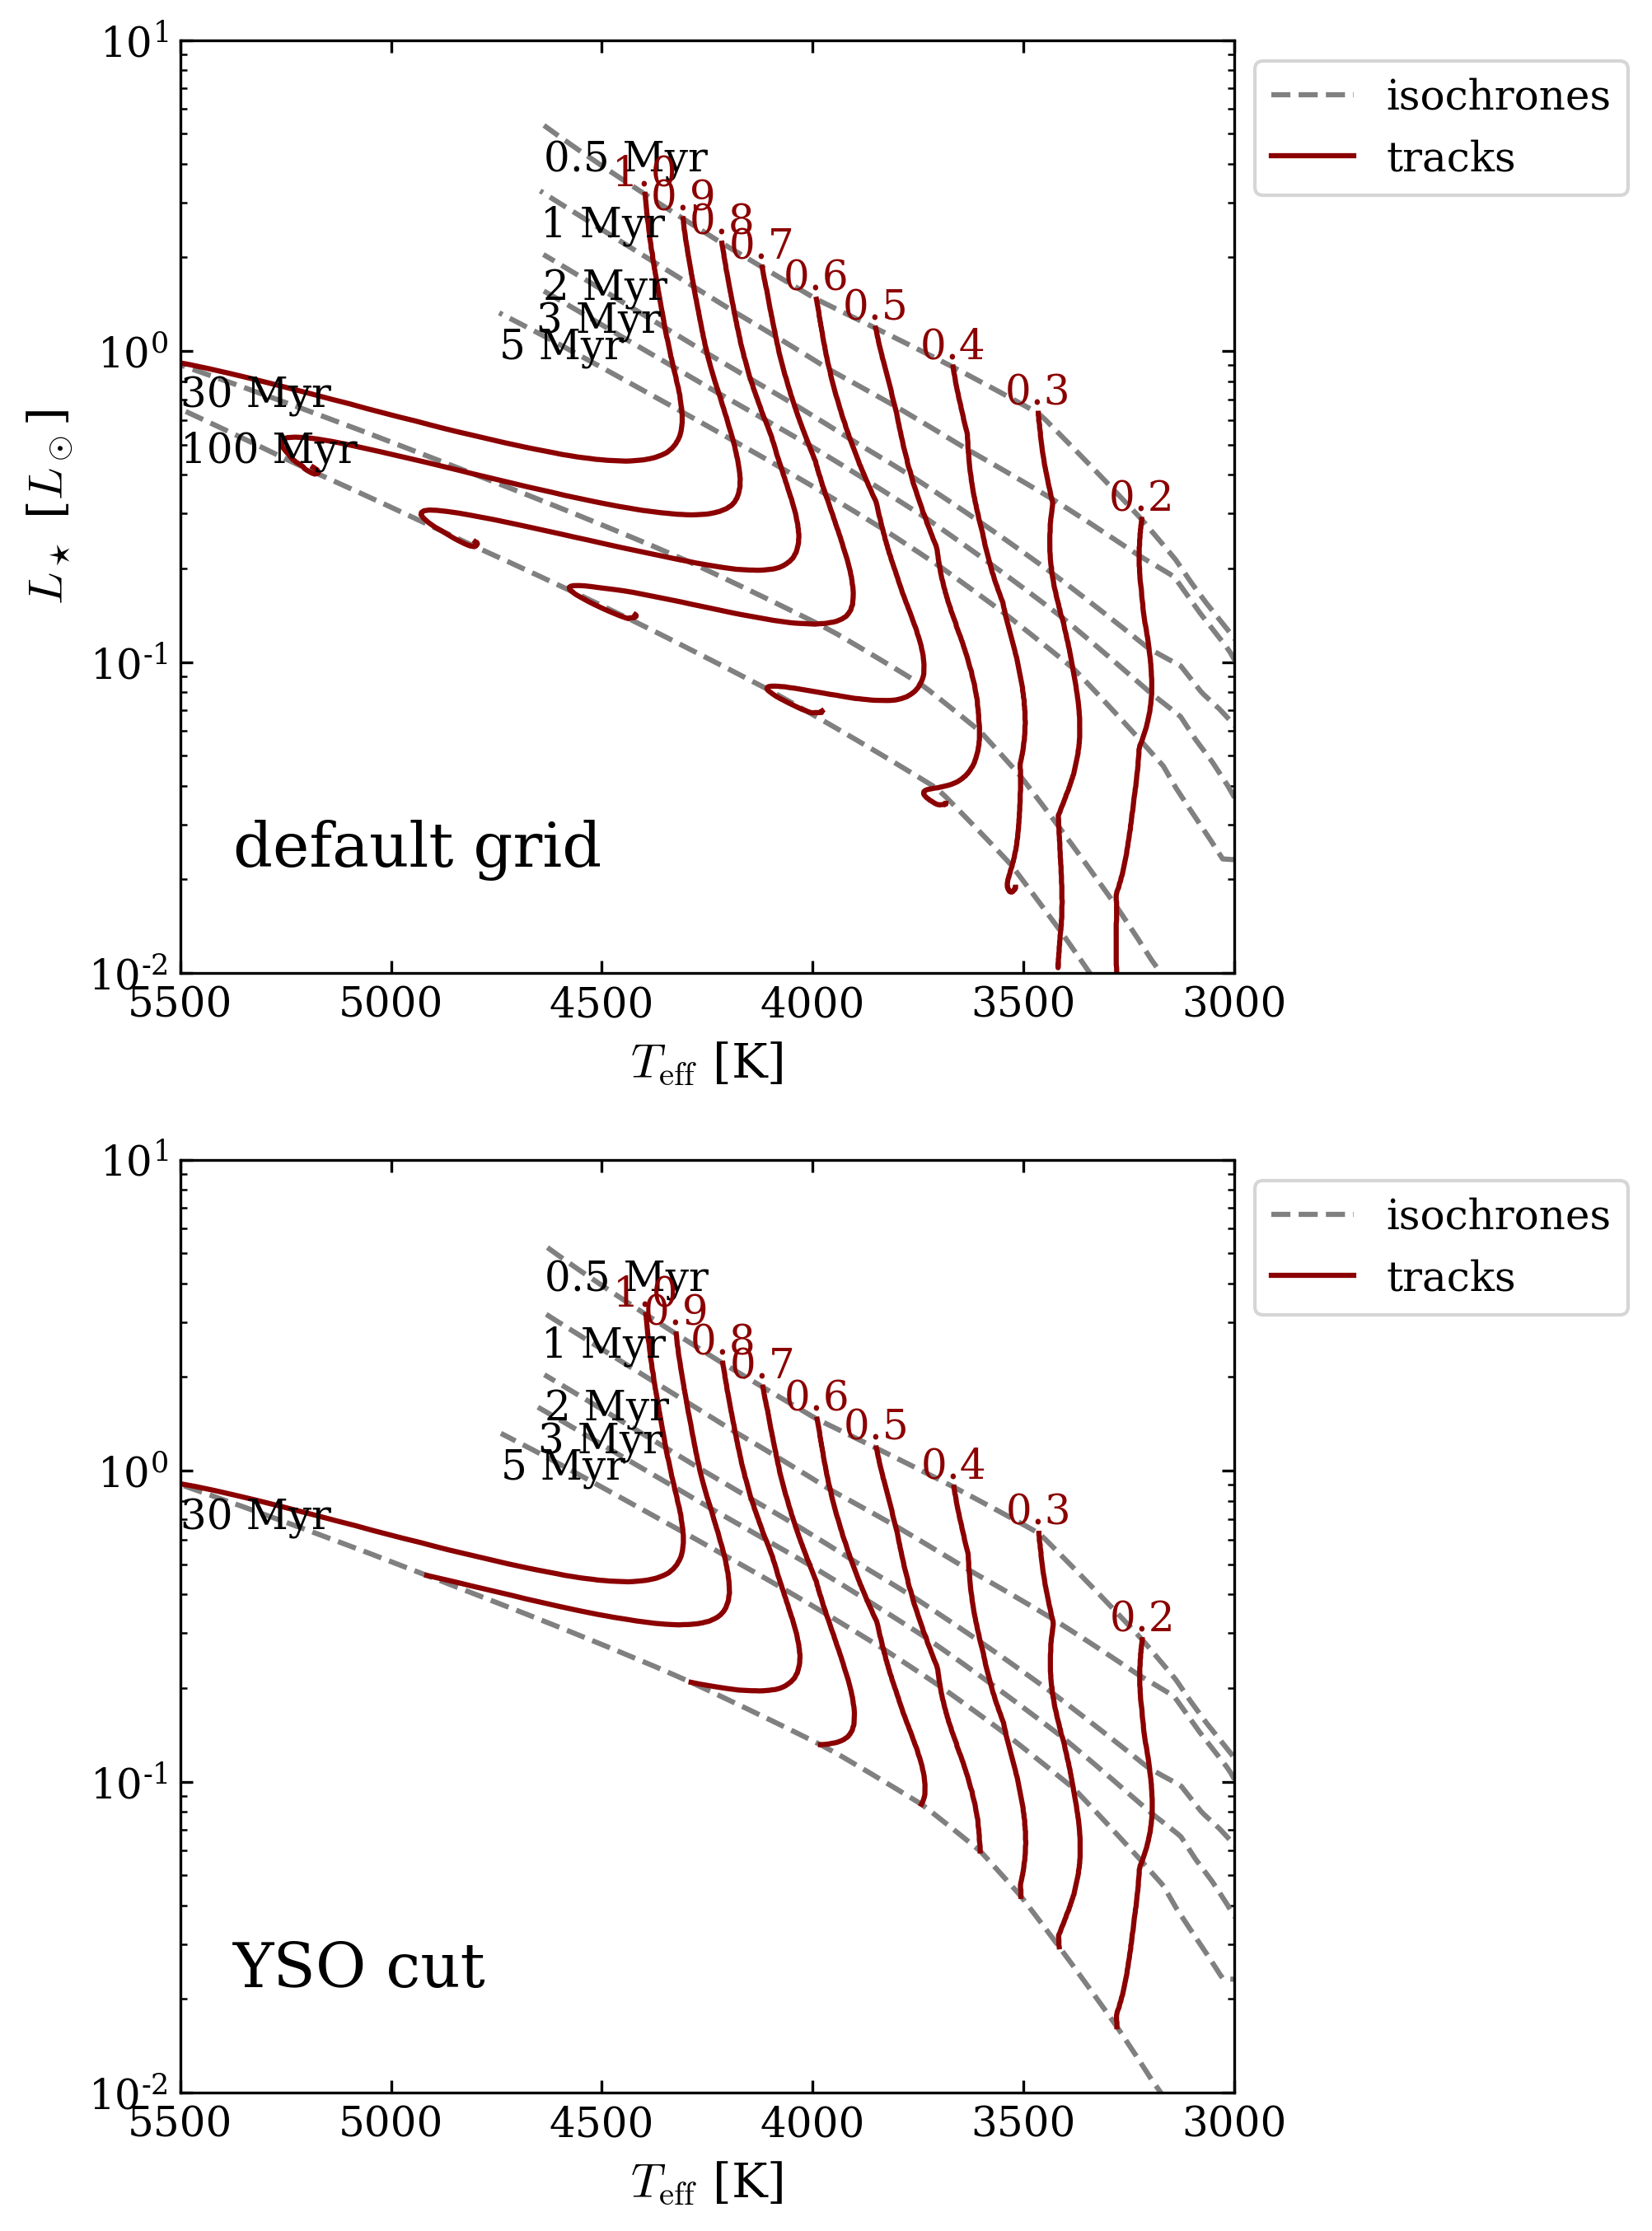

In [14]:
iso_default = ysoisochrone.isochrone.Isochrone()
iso_default.set_tracks('customize', load_file=output_mat_file)

iso_ysocut = ysoisochrone.isochrone.Isochrone()
iso_ysocut.set_tracks('customize', load_file=output_mat_file_ysocut)

for iso, name in [(iso_default, 'default (0.5-1000 Myr, 0-7.5 Msun)'),
                  (iso_ysocut, 'YSO cut (0.5-30 Myr, 0.05-1.4 Msun)')]:
    print(f"{name:38s} | log_age {iso.log_age.min():.2f}..{iso.log_age.max():.2f}"
          f" | mass {iso.masses.min():.3f}..{iso.masses.max():.3f}"
          f" | logtlogl {iso.logtlogl.shape}")

fig, axes = plt.subplots(2, 1, figsize=(5.5, 11), gridspec_kw={'wspace': 0.1})
for ax_t, iso, name in [(axes[0], iso_default, 'default grid'),
                        (axes[1], iso_ysocut, 'YSO cut')]:
    ysoisochrone.plotting.plot_hr_diagram(iso, ax_set=ax_t, xlim_set=[5500, 3000], ylim_set=[0.01, 10.0], zams_curve=False)
    ax_t.annotate(name, xy=(0.05, 0.1), xycoords='axes fraction', ha='left', va='bottom', fontsize=18)
axes[1].set_ylabel('')
plt.show()

Notes:

- `interpolation_method='cubic'` gives smoother isochrones where the raw tracks are
  sparse, at the cost of possible overshoot near the grid edges; `'nearest'` is a robust
  fallback for very irregular data.
- `create_meshgrid_legacy` reproduces the original Pascucci et al. (2016) grid
  (0.5–50 Myr, 0.015–1.4 $M_\odot$) and is kept for backward comparison.
- A future version will trim grid points beyond the zero-age main sequence automatically.

## Derive mass & age with your grid

Finally, point the Bayesian inference at your `.mat` file with `model='customize'`:

  0%|                                                     | 0/1 [00:00<?, ?it/s]


Working on: Sz71
using the user-specified isochrone matrix of
/home/dingshandeng/project/1-Project_ysoisochrone/ysoisochrone/tutorial_notebooks/isochrones_data/Your_matrix_Baraffe_AgeMassGrid_YSO_matrix.mat
-----------------------
Adopted the customize track from /home/dingshandeng/project/1-Project_ysoisochrone/ysoisochrone/tutorial_notebooks/isochrones_data/Your_matrix_Baraffe_AgeMassGrid_YSO_matrix.mat.
using the built-in isochrones
sum of Lmass 99.9999999999043
the last index of Lmass 4.391943707007308e-100
sum of Lmass array 52.57981628431087
the last index of Lmass array 0.9999999999999996
check the sum of confidence interval (default 0.68)
0.6740316957323932


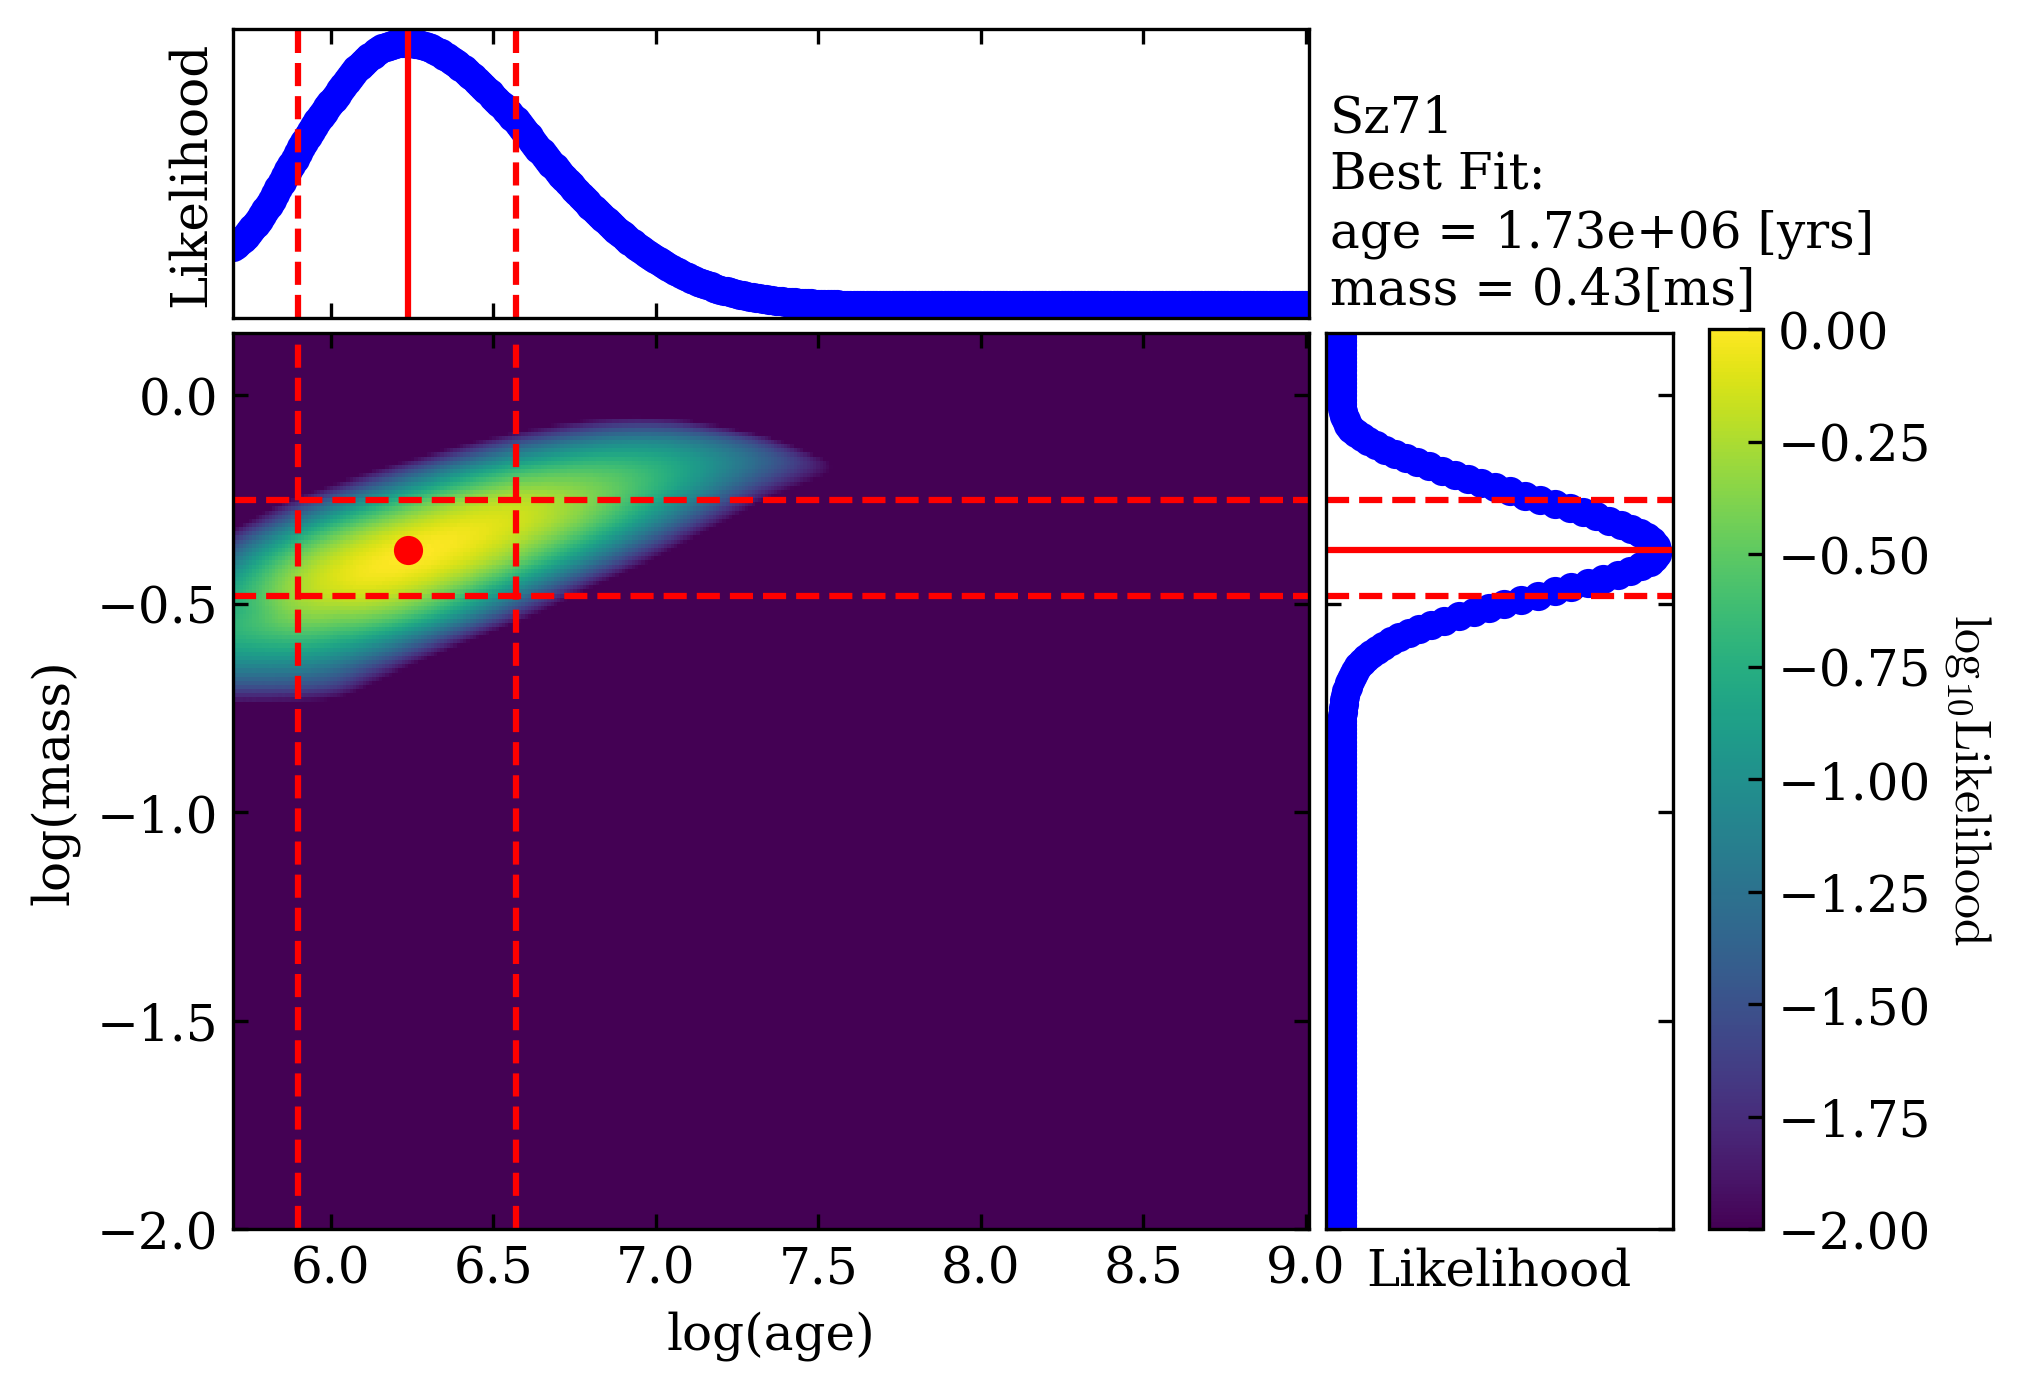

100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  1.54it/s]

Results for target: Sz71
Best Mass: 0.43 [Msun], Age: 1.73e+06 [yrs]
customize tracks (using the built-in isochrones) for 1 targets


In [15]:
# Set up a DataFrame in Python script
# For this target Sz71, values are from Alcala+2017,
# and corrected later with the Gaia DR3 distance in Manara+2023
df_prop_t = pd.DataFrame({
    'Source': ['Sz71'],
    'Teff[K]': np.array([3632.0]),
    'e_Teff[K]': np.array([167.0]),
    'Luminosity[Lsun]': np.array([0.327]),
    'e_Luminosity[Lsun]': np.array([0.1420])
})

# find the best-fit results
best_logmass_output_t, best_logage_output_t, _, _, _ =\
    ysoisochrone.bayesian.derive_stellar_mass_age(df_prop_t, model='customize', plot=True,
                                                  isochrone_mat_file=output_mat_file, verbose=True)